# A/B-анализ персональной промо-кампании: выручка, устойчивость эффекта и диагностика аномалий

Проект посвящен оценке эффективности персональной промо-кампании в ритейле. Кампания была направлена на группу клиентов, которым предложили персональную скидку через email-рассылку. Для оценки эффекта используется контрольная группа клиентов со схожими характеристиками и покупательским поведением.

Основной вопрос анализа: увеличила ли кампания выручку на клиента и можно ли считать этот эффект устойчивым. В ритейле такая проверка не сводится к одному t-test: распределение выручки обычно асимметрично, часть пользователей не покупает вообще, а отдельные клиенты могут приносить непропорционально большую долю продаж. Поэтому помимо основного сравнения ARPU в работе проводится диагностика нулевых покупок, крупных покупателей, дневной динамики и сегментов.

Финальная цель — не только посчитать статистическую значимость, но и объяснить бизнес-механику результата: за счет чего возник прирост, насколько он устойчив и какие ограничения нужно учитывать при принятии решения.

**Ключевые этапы анализа:**

1. **Формирование user-level базы A/B-теста**
   В анализ включаются все пользователи из test и control, включая тех, кто не совершал покупок в конкретном периоде. Это нужно, чтобы не завысить эффект кампании за счет исключения пользователей с нулевой выручкой.

2. **Оценка основного эффекта по ARPU**
   Сравнивается средняя выручка на пользователя в test и control за период кампании. Дополнительно используется bootstrap, чтобы проверить устойчивость разницы ARPU при пересэмплировании пользователей.

3. **Диагностика формы распределения**
   Выручка имеет сильную правую асимметрию: часть пользователей приносит значительно больше остальных. Поэтому дополнительно применяются log-transform и winsorization, чтобы понять, не держится ли эффект только на пользователях с экстремально высокой выручкой.

4. **Проверка влияния крупнейших покупателей**
   Отдельно анализируются клиенты, формирующие верхние 20% выручки, и остальные пользователи. Это помогает понять, связан ли эффект кампании с крупнейшими покупателями или распределен шире.

5. **Проверка конверсии и дневной динамики**
   CR используется как диагностическая метрика: она показывает, какая доля пользователей совершила хотя бы одну покупку. Также анализируется дневная динамика выручки, чтобы проверить, не связан ли итоговый результат с локальной аномалией внутри периода кампании.

6. **Сегментный анализ**
   После проверки общего эффекта анализируются товарные, брендовые и географические сегменты. Цель — понять, в каких направлениях прирост выручки был наиболее выражен и где эффект кампании оказался слабее.

### Загрузка предварительно очищенных данных и проверка возможных противоречий/логических несостыковок

**Пояснения:**
1. Очистка данных была произведена в отдельной работе и представлена в ноутбуке (data cleaning.ipynb)
2. Там же проверялись противоречия (однако, для наглядности, здесь проверка на противоречия продублирована)

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
BASE_DIR = os.getcwd()
DATA_FOLDER = 'data'
IMAGE_FOLDER = 'report_images'

In [69]:
os.makedirs(os.path.join(BASE_DIR, IMAGE_FOLDER), exist_ok=True) # добавление папки для избражений

In [3]:
file_name = 'df_clients_filled.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_clients_filled = pd.read_csv(full_path, dtype={col: 'str' for col in ['id', 'city', 'country']})
df_clients_filled.head()

,id,gender_missed,age,education,city,country,gender
0,0,0.0,36,среднее,1201,32,0.0
1,4,0.0,35,среднее,1134,32,0.0
2,6,1.0,52,среднее,1188,32,1.0
3,7,0.0,37,среднее,1198,32,0.0
4,9,0.0,48,среднее,1134,32,0.0


In [4]:
file_name = 'df_ab_pos.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_ab_pos = pd.read_csv(full_path, dtype={'id': str})
df_ab_pos['is_test_group'] = 1

file_name = 'df_ab_neg.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_ab_neg = pd.read_csv(full_path, dtype={'id': str})
df_ab_neg['is_control_group'] = 1

In [5]:
df_ab_pos.info()
print('\n')
df_ab_neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             5000 non-null   object
 1   is_test_group  5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                5000 non-null   object
 1   is_control_group  5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [57]:
shared_clients = set(df_ab_pos['id']) & set(df_ab_neg['id'])

print(f'Проверка того, что группы не имеют общих клиентов (выборки независимы):\n'
      f'\tСписок общих клиентов:\n'
      f'\t{[cl for cl in shared_clients if len(shared_clients) != 0 ] or "отсутствуют"}')

print(f'Проверка того, что клиенты не задублированы в обеих выборках:\n'
      f'\tКоличество дубликатов для тестовой группы: {df_ab_pos['id'].duplicated().sum()}\n'
      f'\tКоличество дубликатов для контрольной группы: {df_ab_neg['id'].duplicated().sum()}')

Проверка того, что группы не имеют общих клиентов (выборки независимы):
	Список общих клиентов:
	отсутствуют
Проверка того, что клиенты не задублированы в обеих выборках:
	Количество дубликатов для тестовой группы: 0
	Количество дубликатов для контрольной группы: 0


Составление исходного единого датасета со всеми участниками эксперимента, к которому будут притянуты данные с продажами

In [7]:
df_ab_shared = pd.concat([df_ab_pos,df_ab_neg],ignore_index=True).fillna(0)
df_ab_shared

,id,is_test_group,is_control_group
0,88128,1.0,0.0
1,171960,1.0,0.0
2,142117,1.0,0.0
3,114589,1.0,0.0
4,146123,1.0,0.0
...,...,...,...
9995,89121,0.0,1.0
9996,161445,0.0,1.0
9997,162570,0.0,1.0
9998,92547,0.0,1.0


### Дизайн метрик и постэкспериментальные окна

Для оценки кампании формируется user-level витрина: одна строка соответствует одному пользователю из test/control, а выручка агрегируется по выбранным временным окнам. Пользователи без покупок в окне сохраняются в выборке с выручкой 0, чтобы не завышать эффект кампании за счет исключения некупивших клиентов.

#### 1. Основная метрика: ARPU в период кампании

Основная метрика кампании - ARPU. Она отвечает на бизнес-вопрос о средней выручке на назначенного пользователя. В качестве основного статистического теста для ARPU используется t-test Уэлча, так как он сравнивает средние значения двух независимых групп и не требует равенства дисперсий. Остальные методы используются не вместо основного теста, а как диагностика устойчивости результата.

Период кампании: **дни 5–16 включительно**.
Продолжительность: **12 дней**.

Эта метрика отвечает на главный бизнес-вопрос:

*принесла ли тестовая группа больше выручки на одного назначенного клиента, чем контрольная группа?*

#### 2. Guardrail-метрики: ARPU в постпериодах

Так как полноценного сопоставимого pre-period до кампании в данных нет, для диагностики используются постэкспериментальные окна:

- 'arpu_nearest' — ближайший постпериод: **дни 19–30**;
- 'arpu_post' — более поздний сопоставимый постпериод: **дни 47–58**.

Эти окна не используются как основная метрика успеха кампании. Их задача — проверить, не сопровождается ли рост выручки в период промо последующей просадкой.

Guardrail-метрики оцениваются в относительном выражении test к control, так как постпериоды отличаются по общему уровню спроса. Если в постпериодах ARPU test не падает относительно control, явных признаков вымывания будущего спроса не видно.

#### 3. Почему выбран период 47–58

Период **47–58** имеет ту же длину, что и тестовый период, и расположен через 42 дня, то есть через 6 недель. Это позволяет сохранить совпадение по дням недели и снизить влияние недельной сезонности.

Ближайший постпериод **19–30** используется как дополнительная проверка более ранних последствий промо, но он менее чистый с точки зрения календарной сопоставимости.

#### 4. Дополнительные диагностические метрики

Кроме основной ARPU-метрики, в анализе используются:

- 'CR' — доля пользователей с ненулевой выручкой в периоде;
- log-transform — диагностика влияния нулевых значений и асимметрии распределения;
- winsorization и bootstrap — проверки устойчивости результата;
- дневная динамика выручки — проверка локальных аномалий внутри периода кампании.

In [8]:
file_name = 'df_purchases.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_purchases_ab = pd.read_csv(full_path, usecols=['id', 'cost', 'dt', 'week', 'day_of_week', 'base_sale'], dtype={'id': str})
df_purchases_ab = pd.merge(df_ab_shared, df_purchases_ab, how='left', on='id')

period = np.array([5, 16]) # период проведения промо

# определение окна, сопоставимого промо исходному по недельной сезонности (period_compat),
# такого, чтобы  последний день периода был максимально близко к временнóму хвосту датасета
max_post_day = df_purchases_ab['dt'].max() # максимальный день в датасете
next_post_day = period[-1] + 1 # следующий день после промо
post_days_total = max_post_day - next_post_day + 1 # количество дней между окончанием промо и макс днем в датасете (42)
weeks_in_days = post_days_total // 7 * 7 # количество полных недель после промо (здесь 6), выраженное в днях (42)
period_compat = period + weeks_in_days

# определение окна, сопоставимого исходному промо по недельной сезонности (period_compat_ext),
# ближайшего к исходному промо
span_promo = np.diff(period) + 1 # продолжительность промо
span_promo_w = np.ceil(span_promo / 7) * 7 # количество полных недель, которые охватывает промо, выраженное в днях (14)
period_compat_ext = period + span_promo_w

# создание масок по временным окнам
mask_test = (df_purchases_ab['dt'] >= period[0]) & (df_purchases_ab['dt'] <= period[1])
mask_compat = (df_purchases_ab['dt'] >= period_compat[0]) & (df_purchases_ab['dt'] <= period_compat[1])
mask_compat_ext = (df_purchases_ab['dt'] >= period_compat_ext[0]) & (df_purchases_ab['dt'] <= period_compat_ext[1])

# создание колонок-тегов для последующей группировки (crosstab и fillna)
df_purchases_ab.loc[mask_test, 'period'] = 'period_test'
df_purchases_ab.loc[mask_compat, 'period'] = 'period_compatible'
df_purchases_ab.loc[mask_compat_ext, 'period'] = 'period_compatible_ext'

df_purchases_ab

,id,is_test_group,is_control_group,cost,base_sale,dt,week,day_of_week,period
0,88128,1.0,0.0,3499,0,1,1,7,NaN
1,88128,1.0,0.0,4799,1,2,2,1,NaN
2,88128,1.0,0.0,1699,0,4,2,3,NaN
3,88128,1.0,0.0,3499,0,5,2,4,period_test
4,88128,1.0,0.0,3199,0,5,2,4,period_test
...,...,...,...,...,...,...,...,...,...
120221,120689,0.0,1.0,2639,1,32,6,3,NaN
120222,120689,0.0,1.0,1889,1,32,6,3,NaN
120223,120689,0.0,1.0,3399,1,32,6,3,NaN
120224,120689,0.0,1.0,1399,1,44,8,1,NaN


In [9]:
# группировка событий по юнитам (пользователям) и периодам
df_purchases_ab_grouped = (
    df_purchases_ab
    .groupby(['id', 'period'], dropna=False)
    .agg({
        'cost': 'sum',
        'is_test_group': 'mean',
        'is_control_group': 'mean'
    })
    .reset_index()
    .fillna({'period':'period_other'})
    .fillna(0)
)
df_purchases_ab_grouped

,id,period,cost,is_test_group,is_control_group
0,100029,period_compatible,2899,1.0,0.0
1,100029,period_test,8988,1.0,0.0
2,100029,period_other,4248,1.0,0.0
3,100036,period_compatible_ext,5999,1.0,0.0
4,100036,period_test,8498,1.0,0.0
...,...,...,...,...,...
28315,99985,period_other,7599,1.0,0.0
28316,99992,period_compatible,287683,0.0,1.0
28317,99992,period_compatible_ext,250731,0.0,1.0
28318,99992,period_test,560013,0.0,1.0


Итоговый датасет разделяет метрики в отдельные колонки

In [10]:
df_ab = ((pd.crosstab(
    index=[
        df_purchases_ab_grouped['id'],
        df_purchases_ab_grouped['is_control_group'],
        df_purchases_ab_grouped['is_test_group']
    ],
    columns=[df_purchases_ab_grouped['period']],
    values=df_purchases_ab_grouped['cost'],
    aggfunc='sum',
    )
         .fillna(0)
         .reset_index()
         .drop(columns=['period_other']))
         .set_axis(
            ['id', 'is_control_group', 'is_test_group', 'arpu_post','arpu_nearest', 'arpu'],
            axis=1)
        )

df_ab

,id,is_control_group,is_test_group,arpu_post,arpu_nearest,arpu
0,100029,0.0,1.0,2899.0,0.0,8988.0
1,100036,0.0,1.0,0.0,5999.0,8498.0
2,100038,1.0,0.0,0.0,0.0,8297.0
3,100070,1.0,0.0,0.0,52150.0,29895.0
4,10010,0.0,1.0,0.0,0.0,8397.0
...,...,...,...,...,...,...
9995,99930,1.0,0.0,11999.0,0.0,24546.0
9996,9994,0.0,1.0,6499.0,0.0,0.0
9997,99970,0.0,1.0,10598.0,0.0,26671.0
9998,99985,0.0,1.0,0.0,0.0,0.0


### Анализ A/B-теста: почему разные проверки дают разные сигналы

В этом блоке проверяется не только статистическая значимость основной метрики, но и устойчивость результата. Для выручки в ритейле это важно, потому что ее распределение обычно неоднородно: часть клиентов не покупает вообще, часть приносит умеренную выручку, а небольшая группа клиентов формирует правый хвост распределения.

Основная метрика кампании - ARPU. Она отвечает на бизнес-вопрос о средней выручке на назначенного пользователя, но может быть чувствительна к пользователям с очень высокой выручкой. Поэтому дополнительно используются диагностические проверки: bootstrap, log-transform, winsorization и анализ крупнейших покупателей.

Цель этих проверок - не заменить основную метрику, а понять, насколько ей можно доверять и за счет чего сформировался эффект.

Для оценки устойчивости результата используются следующие подходы:

1. **Raw ARPU, проверка значимости по тесту Уелча**:
   Основная бизнес-метрика. Показывает среднюю выручку на пользователя в test и control.

2. **Bootstrap по ARPU**:
   Проверяет устойчивость разницы ARPU при пересэмплировании пользователей.

3. **Log-transform**:
   Снижает влияние пользователей с очень высокой выручкой, но при наличии нулевых значений также отражает различия в CR. Поэтому результат log-transform интерпретируется только вместе с графиком распределения и конверсией.

4. **Winsorization**:
   Ограничивает верхний 1% пользовательской выручки и проверяет, сохраняется ли эффект после уменьшения влияния крупнейших значений.

5. **Анализ top revenue 20%**:
   Отдельно сравниваются клиенты, формирующие верхние 20% выручки, и остальные пользователи. Это помогает проверить, не держится ли эффект только на крупнейших покупателях.

In [11]:
def ab_ttest(df, col, alpha=0.05):

    test = df.loc[df['is_test_group'] == 1, col]
    control = df.loc[df['is_control_group'] == 1, col]

    test_size, control_size = df['is_test_group'].value_counts().sort_index(ascending=False)
    print(f'Тестовая группа: {test_size}\nКонтрольная группа: {control_size}')
    sample_sizes = np.array([test_size, control_size])
    sample_sizes.mean()

    chi_pv = stats.chisquare(sample_sizes, np.full(2, sample_sizes.mean())).pvalue.round(4)
    print(f'На уровне значимости {alpha:.0%} нулевая гипотеза о равенстве выборок = {chi_pv > alpha}, '
          f'(p-value: {chi_pv})')

    levene_pv = stats.levene(test, control).pvalue.round(4)
    print(f'На уровне значимости {alpha:.0%} нулевая гипотеза о равенстве дисперсий в выборках = {levene_pv > alpha} '
          f'(p-value: {levene_pv})')

    ttest = stats.ttest_ind(test, control, equal_var=False)
    metric_t, metric_c = test.mean(), control.mean()
    metric_diff = metric_t - metric_c
    metric_uplift = metric_diff / metric_c

    ci = ttest.confidence_interval(confidence_level=1-alpha)
    print(f'На уровне значимости {alpha:.0%} '
          f'нулевая гипотеза о равенстве средних в выборках = {ttest.pvalue > alpha} '
          f'(p-value: {ttest.pvalue:.3f})')
    print(f'Средние значения в выборках:\n\tтестовая {metric_t:.2f}\n\tконтрольная {metric_c:.2f}')
    print(f'Разница Средних: {metric_diff:.2f}')
    print(f'Доверительный интервал: ({ci[0]:.2f}, {ci[1]:.2f})')

    return [
        round(metric_t, 2), round(metric_c, 2), round(metric_diff, 2), round(metric_uplift * 100, 1),
        [round(ci[0], 2), round(ci[1], 2)], round(ttest.pvalue, 4)
    ]

In [12]:
ab_periods = ['arpu', 'arpu_nearest', 'arpu_post']
df_report = pd.DataFrame(columns=['metric', 'test', 'control', 'difference', 'uplift_%', 'ci', 'p_value']) # яяя

In [13]:
for col in ab_periods:
    print('=' * 60, end='\n\n')
    print(f'{col}', end='\n\n')

    report_list = ab_ttest(df_ab, col=col, alpha=.05)
    df_report.loc[df_report.shape[0], :] = [col] + report_list

    print(f'\n{"=" * 60}')


arpu

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = False (p-value: 0.0001)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = False (p-value: 0.000)
Средние значения в выборках:
	тестовая 26705.90
	контрольная 22367.65
Разница Средних: 4338.25
Доверительный интервал: (2761.15, 5915.35)


arpu_nearest

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = True (p-value: 0.2622)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = True (p-value: 0.229)
Средние значения в выборках:
	тестовая 11273.43
	контрольная 10548.78
Разница Средних: 724.65
Доверительный интервал: (-456.84, 1906.14)


arpu_post

Тестовая группа: 5000
Контрольная г

In [14]:
df_report

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718


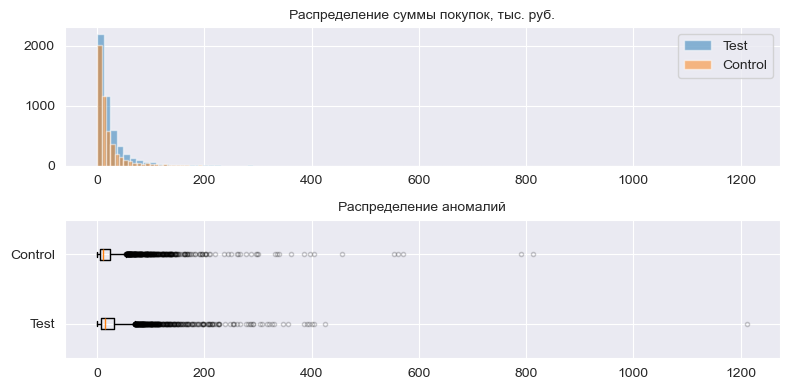

In [15]:
_, ax = plt.subplots(2, 1, figsize=(8, 4))
plt.subplots_adjust(hspace=.4)

groups = []
for gr in df_ab['is_control_group'].unique():
    ser = df_ab.loc[df_ab['is_control_group'] == gr, 'arpu'].divide(1000)
    groups += [ser]
    ax[0].hist(ser, bins=100, alpha=.5)
ax[0].legend(['Test', 'Control'])
ax[0].set_title(f'Распределение суммы покупок, тыс. руб.', fontsize=10)
ax[1].boxplot(groups, tick_labels=['Test', 'Control'],  vert=False, flierprops={'marker':'.', 'alpha':0.2})
ax[1].set_title(f'Распределение аномалий', fontsize=10)

file_name = 'ab_raw_distr.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.tight_layout()
plt.show()

Промежуточный вывод:

- основная метрика выросла статистически значимо, обнаружен эффект прироста на 19.4%
- защитные метрики arpu_post и arpu_nearest статистически значимо не изменились, т.е. смещение спроса из-за влияния промо не обнаружено

Поскольку выручка - метрика очень вариативная, необходимо дополнительно проверить робастность эффекта и степень влияния китов на эффект. Это будет сделано при помощи следующих инструментов:

- Bootstrap
- Winsorization
- Top N
- Log transform

#### Bootstrap

In [16]:
n = 10000
rng = np.random.default_rng(42)
arpu_test_mean = np.empty(n)
arpu_control_mean = np.empty(n)

arpu_test = df_ab.loc[df_ab['is_test_group'] == 1, 'arpu'].values
arpu_control = df_ab.loc[df_ab['is_control_group'] == 1, 'arpu'].values

for i in range(0, n):
    arpu_test_b = rng.choice(arpu_test, size=arpu_test.size, replace=True)
    arpu_control_b = rng.choice(arpu_control, size=arpu_control.size, replace=True)
    arpu_test_mean[i] = arpu_test_b.mean()
    arpu_control_mean[i] = arpu_control_b.mean()

arpu_diff = arpu_test_mean - arpu_control_mean

bt_stat = [
    'arpu_bootstrap',
    round(arpu_test_mean.mean(), 2), round(arpu_control_mean.mean(), 2),
    round(arpu_diff.mean(), 2), round(arpu_diff.mean() / arpu_control_mean.mean() * 100, 1),
    (round(np.quantile(arpu_diff, 0.025), 2), round(np.quantile(arpu_diff, .975), 2)),
    2 * min(np.mean(arpu_diff <= 0), np.mean(arpu_diff >= 0))
    ]

df_report.loc[df_report.shape[0], :] = bt_stat
df_report

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718
3,arpu_bootstrap,26717.03,22365.19,4351.84,19.5,"(2771.12, 5904.74)",0.0


Bootstrap подтвердил значимый uplift по ARPU за период кампании:

- разница ARPU составила около 4 351.84 руб.;
- 95% CI: [2 771; 5 904];
- доверительный интервал не пересекает 0, поэтому положительный эффект по средней выручке устойчив при пересэмплировании пользователей.

#### Log transformation

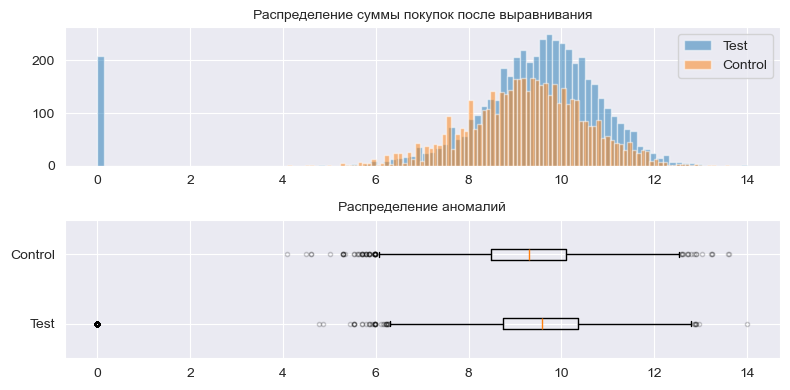

In [17]:
_, ax = plt.subplots(2, 1, figsize=(8, 4))
plt.subplots_adjust(hspace=.4)

groups = []
for gr in df_ab['is_control_group'].unique():
    ser = np.log1p(df_ab.loc[df_ab['is_control_group'] == gr, 'arpu'])
    groups += [ser]
    ax[0].hist(ser, bins=100, alpha=.5)
ax[0].legend(['Test', 'Control'])
ax[0].set_title(f'Распределение суммы покупок после выравнивания', fontsize=10)
ax[1].boxplot(groups, tick_labels=['Test', 'Control'],  vert=False, flierprops={'marker':'.', 'alpha':0.2})
ax[1].set_title(f'Распределение аномалий', fontsize=10)
plt.tight_layout()

file_name = 'ab_log_distr.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.show()

In [18]:
df_ab_log = df_ab.copy()
df_ab_log[ab_periods] = (
    np.log1p(df_ab_log[ab_periods])
)

for col in ab_periods:
    print('=' * 60, end='\n\n')
    print(f'{col}', end='\n\n')

    report_list = ab_ttest(df_ab_log, col=col, alpha=.05)
    report_list[3] = round(np.expm1(report_list[2]) * 100, 1)# корректная интерпретация выручки
    report_list[4] = np.nan
    df_report.loc[df_report.shape[0], :] = [f'{col}_log'] + report_list

    print(f'\n{"=" * 60}')


arpu

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = False (p-value: 0.0)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = False (p-value: 0.035)
Средние значения в выборках:
	тестовая 9.19
	контрольная 9.26
Разница Средних: -0.08
Доверительный интервал: (-0.15, -0.01)


arpu_nearest

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = True (p-value: 0.3588)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = True (p-value: 0.091)
Средние значения в выборках:
	тестовая 5.31
	контрольная 5.16
Разница Средних: 0.15
Доверительный интервал: (-0.02, 0.33)


arpu_post

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости

In [19]:
df_report

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718
3,arpu_bootstrap,26717.03,22365.19,4351.84,19.5,"(2771.12, 5904.74)",0.0
4,arpu_log,9.19,9.26,-0.08,-7.7,NaN,0.0353
5,arpu_nearest_log,5.31,5.16,0.15,16.2,NaN,0.0908
6,arpu_post_log,4.27,3.95,0.32,37.7,NaN,0.0004


По log-transform на данный момент после снижения влияния пользователей с экстремально высокой выручкой в экспериментальном периоде эффект по ARPU снижается и меняет знак, а в постпериодах начинает увеличиваться.

Также график распределения показывает, что log-transform не решает полностью проблему формы распределения: у test сохраняется сильный пик около нуля, из-за чего сравнение средних логов смешивает эффект конверсии и эффект выручки среди платящих.

Таким образом, вероятно, но не доказано:

- типичные пользователи могли не показать роста выручки в период промо, а положительный эффект обычного ARPU мог быть обусловлен китами;
- промо могло повлиять на поведение части пользователей и привести к очень высокой выручке у них в экспериментальном периоде, при этом в постэкспериментальных периодах этот эффект, вероятно, вернулся ближе к основной массе.
- необходимо дополнительно исследовать эффект конверсии, влияющей на распределение (по сути, у контроля нулей нет, в отличие от теста) путем разложения ARPU=CR×ARPPU

In [20]:
df_ab_w = df_ab.copy()

for col in ab_periods:
    print('=' * 60, end='\n\n')
    print(f'{col}', end='\n\n')

    df_ab_w[col] = df_ab_w[col].clip(upper=df_ab_w[col].quantile(.99))
    report_list = ab_ttest(df_ab_w, col=col, alpha=.05)
    df_report.loc[df_report.shape[0], :] = [f'{col}_wnz'] + report_list


arpu

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = False (p-value: 0.0)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = False (p-value: 0.000)
Средние значения в выборках:
	тестовая 25593.19
	контрольная 21313.39
Разница Средних: 4279.80
Доверительный интервал: (3071.00, 5488.61)

arpu_nearest

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = True (p-value: 0.0603)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = True (p-value: 0.051)
Средние значения в выборках:
	тестовая 10344.30
	контрольная 9563.78
Разница Средних: 780.52
Доверительный интервал: (-1.82, 1562.85)

arpu_post

Тестовая группа: 5000
Контрольная группа: 5

In [21]:
df_report

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718
3,arpu_bootstrap,26717.03,22365.19,4351.84,19.5,"(2771.12, 5904.74)",0.0
4,arpu_log,9.19,9.26,-0.08,-7.7,NaN,0.0353
5,arpu_nearest_log,5.31,5.16,0.15,16.2,NaN,0.0908
6,arpu_post_log,4.27,3.95,0.32,37.7,NaN,0.0004
7,arpu_wnz,25593.19,21313.39,4279.8,20.1,"[3071.0, 5488.61]",0.0
8,arpu_nearest_wnz,10344.3,9563.78,780.52,8.2,"[-1.82, 1562.85]",0.0505
9,arpu_post_wnz,7093.72,6610.24,483.48,7.3,"[-128.0, 1094.95]",0.1212


Винзоризация верхнего 1% не ослабила положительный эффект по ARPU. Даже если ограничить влияние крупнейших покупателей, кампания все равно показывает положительный эффект по ARPU: прирост вырос с 19.4% до 20.1%. Значит, результат не выглядит случайным из-за нескольких очень крупных клиентов.

#### Top 20. Исследование эффекта на клиентах, формирующих верхние 20% выручки

In [22]:
df_ab_top = df_ab.copy()

mask_c = df_ab_top['is_test_group'].eq(0)
mask_t = df_ab_top['is_test_group'].eq(1)

for col in ab_periods:
    ser_top = df_ab_top[col].sort_values(ascending=False)
    whales_list = ser_top[ser_top.cumsum() / ser_top.sum() <= .2].index
    mask_whales = df_ab_top.index.isin(whales_list)
    arpu_t = df_ab_top.loc[mask_whales & mask_t, col].mean()
    arpu_c = df_ab_top.loc[mask_whales & mask_c, col].mean()
    arpu_diff_top = arpu_t - arpu_c

    top20_stat = [
        f'{col}_top20',
        round(arpu_t, 2),
        round(arpu_c, 2),
        round(arpu_diff_top, 2),
        round(arpu_diff_top / arpu_c * 100, 1),
        np.nan,
        np.nan
        ]

    df_report.loc[df_report.shape[0], :] = top20_stat

In [23]:
df_report

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718
3,arpu_bootstrap,26717.03,22365.19,4351.84,19.5,"(2771.12, 5904.74)",0.0
4,arpu_log,9.19,9.26,-0.08,-7.7,NaN,0.0353
5,arpu_nearest_log,5.31,5.16,0.15,16.2,NaN,0.0908
6,arpu_post_log,4.27,3.95,0.32,37.7,NaN,0.0004
7,arpu_wnz,25593.19,21313.39,4279.8,20.1,"[3071.0, 5488.61]",0.0
8,arpu_nearest_wnz,10344.3,9563.78,780.52,8.2,"[-1.82, 1562.85]",0.0505
9,arpu_post_wnz,7093.72,6610.24,483.48,7.3,"[-128.0, 1094.95]",0.1212


#### Non-top 20. Исследование эффекта на остальных клиентах

In [24]:
df_ab_top = df_ab.copy()

mask_c = df_ab_top['is_test_group'].eq(0)
mask_t = df_ab_top['is_test_group'].eq(1)

for col in ab_periods:
    ser_top = df_ab_top[col].sort_values(ascending=False)
    notwhales_list = ser_top[ser_top.cumsum() / ser_top.sum() > .2].index
    mask_notwhales = df_ab_top.index.isin(notwhales_list)
    arpu_t = df_ab_top.loc[mask_notwhales & mask_t, col].mean()
    arpu_c = df_ab_top.loc[mask_notwhales & mask_c, col].mean()
    arpu_diff_nottop = arpu_t - arpu_c

    not_top20_stat = [
        f'{col}_non_top20',
        round(arpu_t, 2),
        round(arpu_c, 2),
        round(arpu_diff_nottop, 2),
        round(arpu_diff_nottop / arpu_c * 100, 1),
        np.nan,
        np.nan
        ]

    df_report.loc[df_report.shape[0], :] = not_top20_stat

In [25]:
df_report


,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718
3,arpu_bootstrap,26717.03,22365.19,4351.84,19.5,"(2771.12, 5904.74)",0.0
4,arpu_log,9.19,9.26,-0.08,-7.7,NaN,0.0353
5,arpu_nearest_log,5.31,5.16,0.15,16.2,NaN,0.0908
6,arpu_post_log,4.27,3.95,0.32,37.7,NaN,0.0004
7,arpu_wnz,25593.19,21313.39,4279.8,20.1,"[3071.0, 5488.61]",0.0
8,arpu_nearest_wnz,10344.3,9563.78,780.52,8.2,"[-1.82, 1562.85]",0.0505
9,arpu_post_wnz,7093.72,6610.24,483.48,7.3,"[-128.0, 1094.95]",0.1212


Итого по проверке пользователей, формирующих верхние ~20% выручки. В этой группе test не показывает преимущества над control: uplift в экспериментальном периоде около 0%.

При этом среди остальных пользователей uplift сохраняется на уровне +19.7%. Это говорит, что положительный эффект ARPU не объясняется только крупнейшими покупателями.



Промежуточные результаты исследования эффекта ARPU различными методами:

1. **Raw ARPU вырос**

   Значит, в среднем по всей назначенной аудитории test принес больше выручки.

2. **Bootstrap подтвердил эффект по ARPU**

   Доверительный интервал по разнице ARPU не пересекает ноль, значит положительный эффект по средней выручке устойчив при пересэмплировании пользователей.

3. **Winsorization не ослабила эффект**

   После ограничения влияния самых крупных покупателей uplift не снизился, а немного вырос. Значит, эффект не выглядит случайно раздутым только экстремальными значениями.

4. **Top revenue 20% не объясняет uplift**

   Среди клиентов, формирующих верхние 20% выручки, test не показывает преимущества над control. Значит, крупнейшие покупатели сами по себе не являются источником положительного эффекта.

5. **Non-top revenue показывает положительный uplift**

   Среди остальных клиентов эффект сохраняется. Значит, положительный ARPU-эффект формируется не только на группе крупнейших покупателей.

6. **Log-transform дал отрицательный эффект**

   Но график показывает, что это во многом связано с пиком около нуля в test. Поэтому отрицательный log-effect не отменяет рост ARPU, а показывает неоднородность: в test есть группа пользователей с нулевой/низкой выручкой.

### Исследование конверсии

In [58]:
ab_periods = ['arpu', 'arpu_nearest', 'arpu_post']
ab_periods_names = ['тестовый', 'пост тестовый ближайший', 'пост тестовый']
periods = [period, period_compat_ext, period_compat]
df_cr = pd.DataFrame(index=['Тестовая группа', 'Контрольная группа'])

for per, per_name, per_dates in zip(ab_periods, ab_periods_names, periods):
    mask_zero = df_ab[per].ne(0)
    mask_t = df_ab['is_test_group'].eq(1)
    mask_c = df_ab['is_test_group'].eq(0)

    cr_t = df_ab[mask_t & mask_zero].shape[0] / df_ab[mask_t].shape[0]
    cr_c = df_ab[mask_c & mask_zero].shape[0] / df_ab[mask_c].shape[0]

    print(f'Период: {per_name} (c {int(per_dates[0])} по {int(per_dates[1])} день)')
    print(f'Конверсия покупателей в тестовой группе: {cr_t:.1%}')
    print(f'Конверсия покупателей в контрольной группе: {cr_c:.1%}')
    print(f'\n')

    df_cr[f'CR_{per_name}'] = np.array([cr_t, cr_c]) * 100
    df_report.loc[df_report.shape[0], :] = [
        f'CR{per.replace("arpu", "")}',
        round(cr_t * 100, 1),
        round(cr_c * 100, 1),
        round((cr_t - cr_c) * 100, 1),
        round((cr_t - cr_c)/ cr_c * 100, 1),
        np.nan, np.nan
    ]

Период: тестовый (c 5 по 16 день)
Конверсия покупателей в тестовой группе: 95.8%
Конверсия покупателей в контрольной группе: 100.0%


Период: пост тестовый ближайший (c 19 по 30 день)
Конверсия покупателей в тестовой группе: 58.7%
Конверсия покупателей в контрольной группе: 57.4%


Период: пост тестовый (c 47 по 58 день)
Конверсия покупателей в тестовой группе: 48.1%
Конверсия покупателей в контрольной группе: 44.5%




In [27]:
df_report

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
1,arpu_nearest,11273.43,10548.78,724.65,6.9,"[-456.84, 1906.14]",0.2293
2,arpu_post,7934.32,7748.41,185.91,2.4,"[-823.21, 1195.04]",0.718
3,arpu_bootstrap,26717.03,22365.19,4351.84,19.5,"(2771.12, 5904.74)",0.0
4,arpu_log,9.19,9.26,-0.08,-7.7,NaN,0.0353
5,arpu_nearest_log,5.31,5.16,0.15,16.2,NaN,0.0908
6,arpu_post_log,4.27,3.95,0.32,37.7,NaN,0.0004
7,arpu_wnz,25593.19,21313.39,4279.8,20.1,"[3071.0, 5488.61]",0.0
8,arpu_nearest_wnz,10344.3,9563.78,780.52,8.2,"[-1.82, 1562.85]",0.0505
9,arpu_post_wnz,7093.72,6610.24,483.48,7.3,"[-128.0, 1094.95]",0.1212


In [28]:
# проверка, не попали ли в сезонность во время проведения эксперимента
file_name = 'df_purchases.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_purchases = pd.read_csv(full_path, usecols=['id', 'cost', 'dt', 'week', 'day_of_week', 'base_sale'], dtype={'id': str})
df_purchases = pd.merge(df_purchases, df_clients_filled[['id', 'city']], on='id', how='left')

for per_dates, per_name in zip(periods, ab_periods_names):
    df_cr[f'{per_name} млн.'] = int(df_purchases[df_purchases['dt'].between(per_dates[0], per_dates[1])]['cost'].sum() / 1e6)
df_cr

,CR_тестовый,CR_пост тестовый ближайший,CR_пост тестовый,тестовый млн.,пост тестовый ближайший млн.,пост тестовый млн.
Тестовая группа,95.82,58.72,48.1,1281,756,636
Контрольная группа,100.00,57.38,44.5,1281,756,636


В период эксперимента общая выручка сети была выше, чем в постпериодах: 1281 млн против 756 млн и 636 млн. Значит, экспериментальный период попал в более активный период продаж, и это нужно учитывать при интерпретации абсолютных уровней выручки. Но это не объясняет само по себе разницу CR между test/control, потому что обе группы находятся в одном и том же календарном периоде.

In [29]:
# косвенная проверка, что пользователи, которые не были активны в промо в тесте, все-таки существуют в транзакционной истории
# по их активности во во всем исходном датасете продаж df_purchases
# определяется как разница множеств тестовой группы пользователей и пользователей всего пула активности (df_purchases)

test_list = df_ab.loc[df_ab['is_test_group'].eq(1), 'id'].to_list()
control_list = df_ab.loc[df_ab['is_test_group'].eq(0), 'id'].to_list()
print(f'Количество пользователей тестовой группы,'
      f' которые вообще не проявляли активность в течение периода в 58 дней:\n'
      f'{len(set(test_list) - set(df_purchases['id']))}')

Количество пользователей тестовой группы, которые вообще не проявляли активность в течение периода в 58 дней:
0


CR использовалась как диагностическая метрика. В период кампании конверсия в обеих группах была почти потолочной: 95.8% в test и 100.0% в control. Это означает, что рост ARPU в test не связан с увеличением доли покупателей. Однако требует выяснения причины, как промо могло снизить конверсию, с чем это связано? Также подозрительной выглядит чрезмерно высокая конверсия у двух групп на стадии эксперимента, при том, что снижение активности кажется логичным и не противоречит природе снижения retention.

В постпериодах CR групп близка: 58.7% vs 57.4% и 48.1% vs 44.5%. Это косвенно подтверждает, что после промо группы не выглядят сильно различающимися по покупательской активности и были подобраны относительно корректно.

При этом экспериментальный период совпал с более высоким уровнем продаж по всей сети, поэтому абсолютные значения выручки в период кампании нужно интерпретировать осторожно.

### Исследование динамики поведения выручки во времени среди всех пользователей и в контрольной и тестовой группах в частности

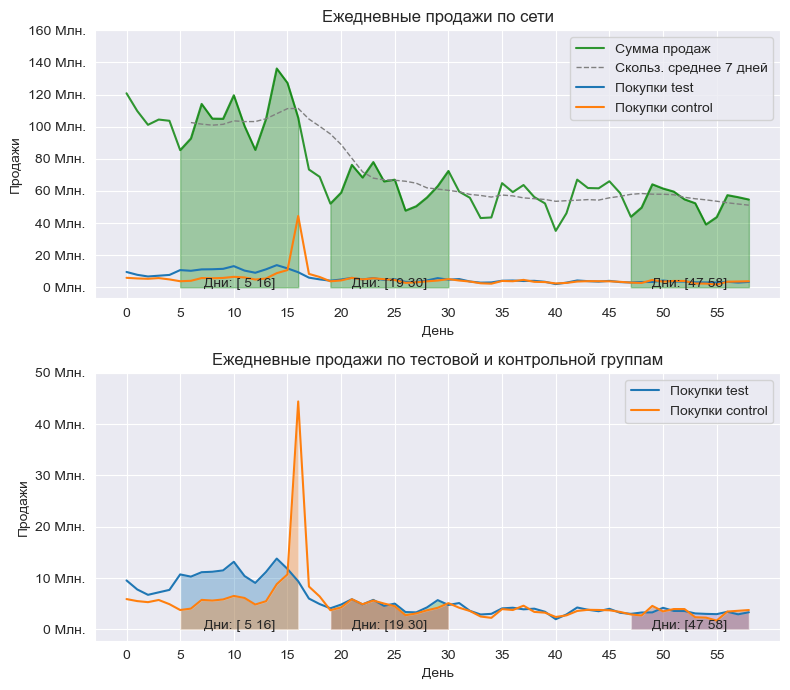

In [75]:
# построение графиков временных рядов
# построение графиков временных рядов
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 7))

daily_sum = df_purchases.groupby('dt')['cost'].sum()
daily_sum.plot(ax=ax, color='green', alpha=.8, label='Сумма продаж')

daily_sum.rolling(7, 7).sum().div(7).plot(ax=ax, color='grey', linestyle='--', linewidth=1, label='Скольз. среднее 7 дней')

mask_t = df_purchases['id'].isin(test_list)
mask_c = df_purchases['id'].isin(control_list)
df_purchases[mask_t].groupby('dt')['cost'].sum().plot(ax=ax, label='Покупки test')
df_purchases[mask_c].groupby('dt')['cost'].sum().plot(ax=ax, label='Покупки control')


for per_dates in periods:
    span = daily_sum.index.where((daily_sum.index >= per_dates[0]) &(daily_sum.index <= per_dates[1]))
    ax.fill_between(span, 0, daily_sum, alpha=.33, color='green')
    ax.text(per_dates.mean(), 0, f'Дни: {per_dates.astype(int)}', ha='center')


ax.set_xlabel('День')
ax.set_ylabel('Продажи')
ax.set_title('Ежедневные продажи по сети')
ax.set_xticks(ticks=range(int(daily_sum.index.min()), int(daily_sum.index.max()) + 1, 5))
ax.set_yticks(ax.get_yticks()[1:])
ax.set_yticklabels([f'{t/1e6:.0f} Млн.' for t in ax.get_yticks()])
ax.legend()


daily_sum_test = df_purchases[mask_t].groupby('dt')['cost'].sum()
daily_sum_control = df_purchases[mask_c].groupby('dt')['cost'].sum()

daily_sum_test.plot(ax=ax2, label='Покупки test')
daily_sum_control.plot(ax=ax2, label='Покупки control')

for per_dates in periods:
    span_test = daily_sum_test.index.where((daily_sum_test.index >= per_dates[0]) &(daily_sum_test.index <= per_dates[1]))
    span_control = daily_sum_control.index.where((daily_sum_control.index >= per_dates[0]) &(daily_sum_control.index <= per_dates[1]))
    ax2.fill_between(span_test, 0, daily_sum_test, alpha=.33)
    ax2.fill_between(span_control, 0, daily_sum_control, alpha=.33)
    ax2.text(per_dates.mean(), 0, f'Дни: {per_dates.astype(int)}', ha='center')

ax2.set_xlabel('День')
ax2.set_ylabel('Продажи')
ax2.set_title('Ежедневные продажи по тестовой и контрольной группам')
ax2.set_xticks(ticks=range(int(daily_sum_test.index.min()), int(daily_sum_test.index.max()) + 1, 5))
ax2.set_yticks(ax2.get_yticks()[1:])
ax2.set_yticklabels([f'{t/1e6:.0f} Млн.' for t in ax2.get_yticks()])
ax2.legend()

file_name = 'daily_sales.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [31]:
mask_5_15 = df_purchases['dt'].between(5, 15)
mask_16 = df_purchases['dt'].eq(16)
mask_c = df_purchases['id'].isin(control_list)

total_uplift_control_16 = (df_purchases[mask_c & mask_16]['cost'].sum() -
                        df_purchases[mask_c & mask_5_15].groupby('dt')['cost'].sum().mean())
print(f'Абсолютный прирост выручки за 16й день по отношению к baseline:\n {total_uplift_control_16:,.2f}'.replace(',', ' '), 'руб.')

Абсолютный прирост выручки за 16й день по отношению к baseline:
 38 294 240.55 руб.


Согласно графику выше, в ежедневной выручке контрольной группы наблюдается резкий скачок на 16-й день. На уровне всей сети в этот день нет сопоставимого всплеска, поэтому аномалия выглядит локальной для контрольной группы.

Абсолютный прирост выручки control на 16-й день относительно среднего дневного уровня control за дни 5–15 составил 38.3 млн руб.

Для проверки природы аномалии далее проверяются гипотезы:

- **(1) Влияние китов на 16-й день**:
  Проверяется доля выручки, которую приносит top-1% пользователей, в сравнении с test/control/total по дням.

- **(2) Изменение активности пользователей**:
  Проверяется DAU/Active users промо периода, где Active users — количество пользователей, активных в период проведения промо. Цель — понять, связан ли скачок с массовым ростом числа покупателей в control.

- **(3) Изменение товарной структуры**:
  Проверяется, не объясняется ли скачок отдельными товарными категориями/брендами. Для этого сравнивается относительный скачок выручки в сегментах на 16-й день относительно среднего уровня за дни 5–15.

- **(4) Изменение географической структуры**:
  Проверяется, не связан ли скачок с отдельными городами. Логика аналогична товарной проверке: сравнивается относительный скачок выручки городов на 16-й день относительно baseline 5–15.

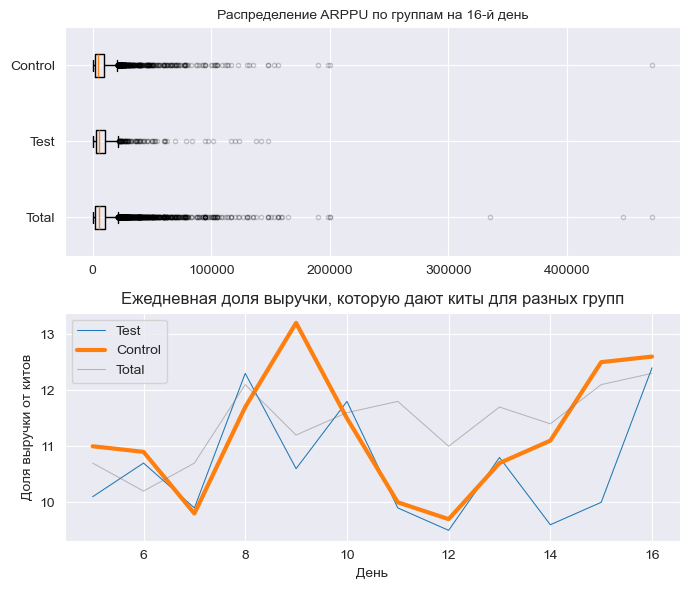

In [76]:
# ниже проверяется гипотеза (1)
df_whales = pd.DataFrame(columns=['test', 'control', 'total'])
for day in range(period[0], period[-1]+1):
    rev_test_16 = df_purchases[mask_t & df_purchases['dt'].eq(day)].groupby('id')['cost'].sum()
    rev_control_16 = df_purchases[mask_c & df_purchases['dt'].eq(day)].groupby('id')['cost'].sum()
    rev_total_16 = df_purchases[df_purchases['dt'].eq(day)].groupby('id')['cost'].sum()

    row = []
    for ser in [rev_test_16, rev_control_16, rev_total_16]:
        mask_99q = ser > ser.quantile(.99)
        row += [round(ser[mask_99q].sum() / ser.sum() * 100, 1)]
    df_whales.loc[day, :] = row

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(7, 6))

ax.boxplot([rev_total_16, rev_test_16, rev_control_16, ], tick_labels=['Total', 'Test', 'Control'],  vert=False, flierprops={'marker':'.', 'alpha':0.2})
ax.set_title(f'Распределение ARPPU по группам на 16-й день', fontsize=10)

df_whales.plot(ax=ax2)
ax2.set_title('Ежедневная доля выручки, которую дают киты для разных групп')
ax2.set_xlabel('День')
ax2.set_ylabel('Доля выручки от китов')

lines = ax2.get_lines()
lines[0].set_linewidth(.75)
lines[1].set_linewidth(3)
lines[2].set_linewidth(.75)
lines[2].set_alpha(0.5)
lines[2].set_color('grey')
ax2.legend(lines, ['Test', 'Control', 'Total'])

file_name = 'whale_contribution.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.tight_layout();

Скачок выручки в control на 16-й день не объясняется повышенной концентрацией выручки у top-1% клиентов.
Доля выручки top-1% в control на 16-й день сопоставима с другими днями и с тестовой группой. Это позволяет отвергнуть гипотезу о том, что скачок на 16-й день вызван именно экстремальной концентрацией выручки в top-1%.

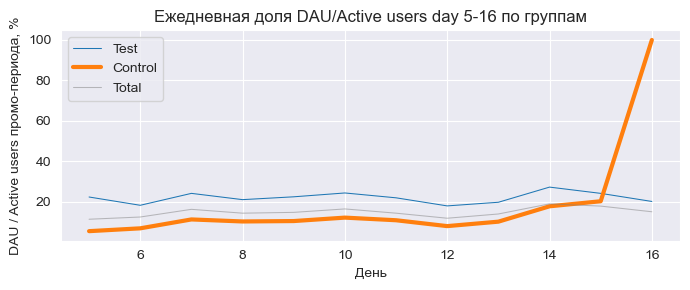

In [77]:
# ниже проверяется гипотеза (2)
df_active_users_16 = pd.DataFrame(columns=['test', 'control', 'total'])
mask_period = df_purchases['dt'].between(period[0], period[-1])

for day in range(period[0], period[-1]+1):
    daily_list = []
    for mask in [mask_t, mask_c, True]:
        mask_d = df_purchases['dt'].eq(day)
        daily_list += [round(df_purchases.loc[mask & mask_d, 'id'].nunique() / df_purchases.loc[mask & mask_period, 'id'].nunique() * 100, 1)]
    df_active_users_16.loc[day, :] = daily_list

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

df_active_users_16.plot(ax=ax)
ax.set_title('Ежедневная доля DAU/Active users day 5-16 по группам')
ax.set_xlabel('День')
ax.set_ylabel('DAU / Active users промо-периода, %')

lines = ax.get_lines()
lines[0].set_linewidth(.75)
lines[1].set_linewidth(3)
lines[2].set_linewidth(.75)
lines[2].set_alpha(0.5)
lines[2].set_color('grey')
ax.legend(lines, ['Test', 'Control', 'Total'])

file_name = 'active_users.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.tight_layout();

In [34]:
# дополнительная проверка конверсии для контрольной группы в день 16
round(df_purchases[mask_c & df_purchases['dt'].eq(16)]['id'].nunique() / df_ab['is_test_group'].eq(0).sum() * 100, 1)

np.float64(100.0)

In [35]:
# проверка конверсии на период промо без аномального дня для тестовой и контрольной группы
print(f'Конверсия в период проведения промо за исключением аномального дня №16:')
for clients, n in zip([test_list, control_list], ['Test', 'Control']):
    cr = (
        df_purchases
        .loc[df_purchases['dt'].between(5,15) & df_purchases['id'].isin(clients), 'id']
        .nunique() / len(clients)
    )
    print(f'\tдля {n} - {cr:.1%}')

Конверсия в период проведения промо за исключением аномального дня №16:
	для Test - 93.6%
	для Control - 60.3%


на 16й день в контрольной группе наблюдается аномальный всплеск, который объясняет 100% конверсию в контрольной группе во время проведения теста. Значит, скачок выручки в control не выглядит следствием вклада узкой группы крупных покупателей и в значительной степени связан с массовой активностью клиентов на 16-й день промо. Таким образом, результат A/B за 5–16 может быть чувствителен к локальной аномалии control на последнем дне.


In [36]:
# ниже проверяется гипотеза (3) и (4) об изменении в каком-то конкретном сегменте категории товаров или гео
file_name = 'df_purchases.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_purchases_all = pd.read_csv(full_path, dtype={'id': str})

Функция top_share() ниже используется для проверки, есть ли отдельный сегмент, который объясняет скачок выручки в контрольной группе на 16-й день.

Логика функции:

1. Берется контрольная группа и baseline-период 5–15.
2. Для выбранного признака ('product_name', 'product_brand', 'city') считается суммарная выручка по сегментам.
3. Оставляются только значимые сегменты, которые вместе формируют основную часть baseline-выручки.
4. Для каждого сегмента считается относительный скачок выручки на 16-й день как:

   *выручка сегмента на 16-й день / средняя дневная выручка сегмента за дни 5–15*

5. Выделяются верхние 20% сегментов с самой высокой долей.
6. Считается, какую часть общего прироста выручки control на 16-й день составляют эти наиболее аномальные сегменты.

Если этот относительный скачок выручки высокий на фоне остальных, он может быть связан с отдельными сегментами.
Если скачок низкий, он, скорее всего, распределен шире и не объясняется одним очевидным товарным, брендовым или географическим драйвером.

In [80]:
def top_share (df, col='product_name', start=5, end=15, share=.99, anomaly_share=.8):
    df_purchases_products = df.loc[df['id'].isin(control_list) & df['dt'].between(start, end), ['cost', col, 'dt']]
    ser_prod = df_purchases_products.groupby(col)['cost'].sum().sort_values(ascending=False)
    prod_share_cum = ser_prod.cumsum() / ser_prod.sum()
    list_top_prod = prod_share_cum[prod_share_cum < share].index.values
    mask = df['id'].isin(control_list) & df['dt'].between(5, 16) & df[col].isin(list_top_prod)
    df_p = df.loc[mask, ['cost', col, 'dt']]

    top_ct = pd.crosstab(
        index=df_p['dt'],
        columns=df_p[col],
        values=df_p['cost'],
        aggfunc='sum'
    ).fillna(0)

    sales_avg = top_ct.loc[:15, :].mean()
    top_ct_norm = top_ct / sales_avg
    sales_16_norm = top_ct_norm.loc[16, :]

    fig, ax = plt.subplots(1, 1, figsize=(7, 3))
    plt.hist(sales_16_norm, bins=50)
    ax.set_title(f'Распределение скачка относительной выручки по {col} на 16 день')
    ax.set_xlabel(f'Уровень скачка относительной выручки на 16-й день\n'
                  f'день 16 / среднее за дни 5–15')
    ax.set_ylabel('Количество сегментов')

    file_name = f'segment_check_{col}.png'
    full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
    plt.savefig(full_path, bbox_inches='tight')
    #plt.tight_layout()

    anom_list = top_ct_norm.T[sales_16_norm > sales_16_norm.quantile(anomaly_share)].index
    uplift_16 = top_ct.loc[16, :] - sales_avg
    return uplift_16[uplift_16.index.isin(anom_list)].sum()


Общий прирост за 16 день в контрольной группе:
	38 294 240.55

Прирост среди наиболее аномальных сегментов в product_name:
	4 887 587.64
Прирост среди наиболее аномальных сегментов в product_name:
	12.8%

Прирост среди наиболее аномальных сегментов в product_brand:
	7 053 203.27
Прирост среди наиболее аномальных сегментов в product_brand:
	18.4%

Прирост среди наиболее аномальных сегментов в city:
	5 224 020.82
Прирост среди наиболее аномальных сегментов в city:
	13.6%



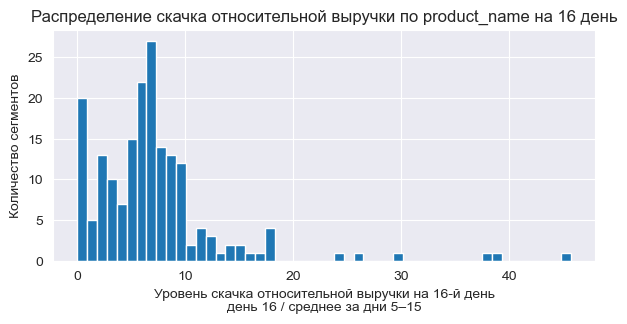

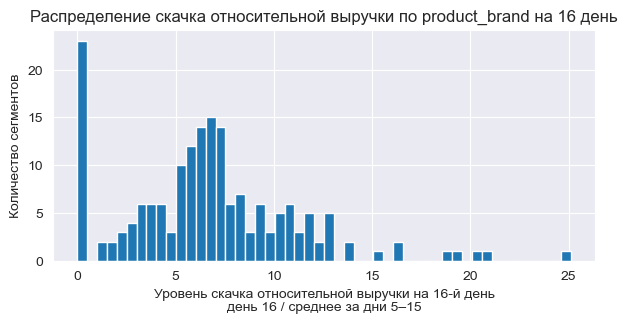

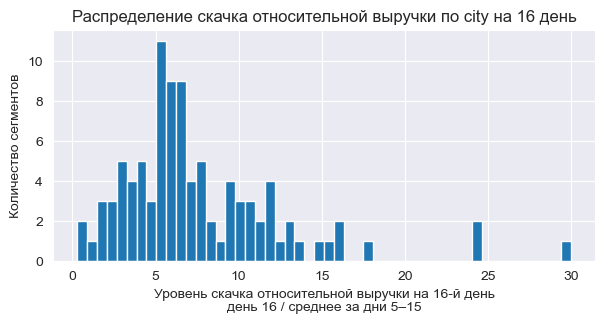

In [81]:
print(f'Общий прирост за 16 день в контрольной группе:\n'
      f'\t{total_uplift_control_16:,.2f}'.replace(',', ' '), end='\n\n')

for i, df in enumerate([df_purchases_all, df_purchases]):
    if i == 0:
        for col in ['product_name', 'product_brand',]:
            # здесь проверяется гипотеза (3) об изменении в каком-то конкретном сегменте товаров
            anom_uplift = top_share(df, col)
            print(f'Прирост среди наиболее аномальных сегментов в {col}:\n'
                  f'\t{anom_uplift:,.2f}'.replace(',', ' '))
            print(f'Прирост среди наиболее аномальных сегментов в {col}:\n'
                  f'\t{anom_uplift/total_uplift_control_16:,.1%}'.replace(',', ' '), end='\n\n')
    else:
        # здесь проверяется гипотеза (4) об изменении в каком-то конкретном гео сегменте
        anom_uplift = top_share(df, 'city')
        print(f'Прирост среди наиболее аномальных сегментов в city:\n'
              f'\t{anom_uplift:,.2f}'.replace(',', ' '))
        print(f'Прирост среди наиболее аномальных сегментов в city:\n'
              f'\t{anom_uplift/total_uplift_control_16:,.1%}'.replace(',', ' '), end='\n\n')

Верхние 20% наиболее аномальных сегментов по индексу выручки объясняют только 12–18% общего прироста control на 16-й день. Это не похоже на ситуацию, где скачок вызван одной категорией, брендом или городом. Скорее прирост был распределен достаточно широко по разным сегментам.

Таким образом,

- нельзя выделить один очевидный сегмент-драйвер аномалии
- скачок control на 16-й день не выглядит вызванным китами или каким-то одним товарным, брендовым либо географическим сегментом
- на 16-й день произошел широкий массовый всплеск активности контрольной группы, источник которого не восстанавливается из доступных данных
- полный период 5–16 загрязнен аномалией в control на 16-й день, поэтому результат будет дополнительно проверен на периоде 5–15 как диагностика

### Проверка устойчивости основной метрики на 5-15 день (Пересчет A/B без аномального дня)

In [39]:
df_purchases_ab_5_15 =df_purchases_ab.copy()

period_5_15 = np.array([5, 15])
mask_exp = df_purchases_ab_5_15['dt'].between(period_5_15[0], period_5_15[1])
df_purchases_ab_5_15['period'] = None
df_purchases_ab_5_15.loc[mask_exp, 'period'] = 'period_5_15'

df_purchases_ab_5_15

,id,is_test_group,is_control_group,cost,base_sale,dt,week,day_of_week,period
0,88128,1.0,0.0,3499,0,1,1,7,None
1,88128,1.0,0.0,4799,1,2,2,1,None
2,88128,1.0,0.0,1699,0,4,2,3,None
3,88128,1.0,0.0,3499,0,5,2,4,period_5_15
4,88128,1.0,0.0,3199,0,5,2,4,period_5_15
...,...,...,...,...,...,...,...,...,...
120221,120689,0.0,1.0,2639,1,32,6,3,None
120222,120689,0.0,1.0,1889,1,32,6,3,None
120223,120689,0.0,1.0,3399,1,32,6,3,None
120224,120689,0.0,1.0,1399,1,44,8,1,None


In [40]:
# группировка событий по юнитам (пользователям) и периодам
df_5_15_grouped = (
    df_purchases_ab_5_15
    .groupby(['id', 'period'], dropna=False)
    .agg({
        'cost': 'sum',
        'is_test_group': 'mean',
        'is_control_group': 'mean'
    })
    .reset_index()
    .fillna({'period':'period_other'})
    .fillna(0)
)
df_5_15_grouped


,id,period,cost,is_test_group,is_control_group
0,100029,period_5_15,8988,1.0,0.0
1,100029,period_other,7147,1.0,0.0
2,100036,period_5_15,8498,1.0,0.0
3,100036,period_other,5999,1.0,0.0
4,100038,period_5_15,5098,0.0,1.0
...,...,...,...,...,...
17581,99970,period_5_15,26671,1.0,0.0
17582,99970,period_other,17097,1.0,0.0
17583,99985,period_other,7599,1.0,0.0
17584,99992,period_5_15,482216,0.0,1.0


In [41]:
df_ab_5_15 = ((pd.crosstab(
    index=[
        df_5_15_grouped['id'],
        df_5_15_grouped['is_control_group'],
        df_5_15_grouped['is_test_group']
    ],
    columns=[df_5_15_grouped['period']],
    values=df_5_15_grouped['cost'],
    aggfunc='sum',
    )
         .fillna(0)
         .reset_index()
         .drop(columns=['period_other']))
         .set_axis(
            ['id', 'is_control_group', 'is_test_group', 'arpu_5_15'],
            axis=1)
        )

df_ab_5_15

,id,is_control_group,is_test_group,arpu_5_15
0,100029,0.0,1.0,8988.0
1,100036,0.0,1.0,8498.0
2,100038,1.0,0.0,5098.0
3,100070,1.0,0.0,23396.0
4,10010,0.0,1.0,8397.0
...,...,...,...,...
9995,99930,1.0,0.0,17147.0
9996,9994,0.0,1.0,0.0
9997,99970,0.0,1.0,26671.0
9998,99985,0.0,1.0,0.0


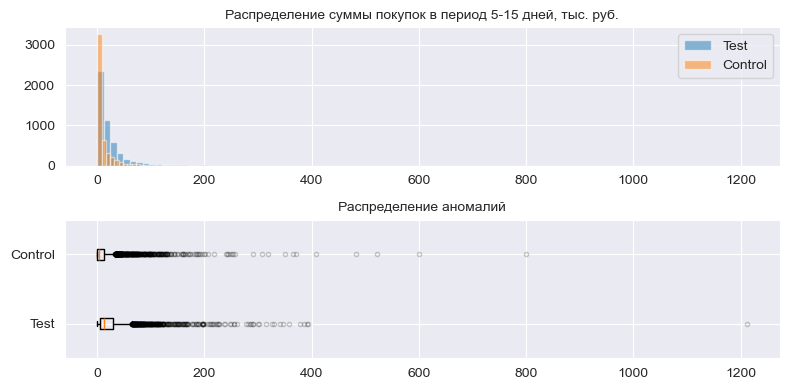

In [42]:
_, ax = plt.subplots(2, 1, figsize=(8, 4))
plt.subplots_adjust(hspace=.4)

groups = []
for gr in df_ab_5_15['is_control_group'].unique():
    ser = df_ab_5_15.loc[df_ab_5_15['is_control_group'] == gr, 'arpu_5_15'].divide(1000)
    groups += [ser]
    ax[0].hist(ser, bins=100, alpha=.5)
ax[0].legend(['Test', 'Control'])
ax[0].set_title(f'Распределение суммы покупок в период 5-15 дней, тыс. руб.', fontsize=10)
ax[1].boxplot(groups, tick_labels=['Test', 'Control'],  vert=False, flierprops={'marker':'.', 'alpha':0.2})
ax[1].set_title(f'Распределение аномалий', fontsize=10)

file_name = 'ab_raw_5_15_distr.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [43]:
print('=' * 60, end='\n\n')
print(f'arpu_5_15', end='\n\n')

report_list = ab_ttest(df_ab_5_15, col='arpu_5_15', alpha=.05)
df_report.loc[df_report.shape[0], :]  = ['arpu_5_15'] + report_list

print(f'\n{"=" * 60}')


arpu_5_15

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = False (p-value: 0.0)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = False (p-value: 0.000)
Средние значения в выборках:
	тестовая 24832.06
	контрольная 13483.06
Разница Средних: 11349.00
Доверительный интервал: (9917.66, 12780.34)



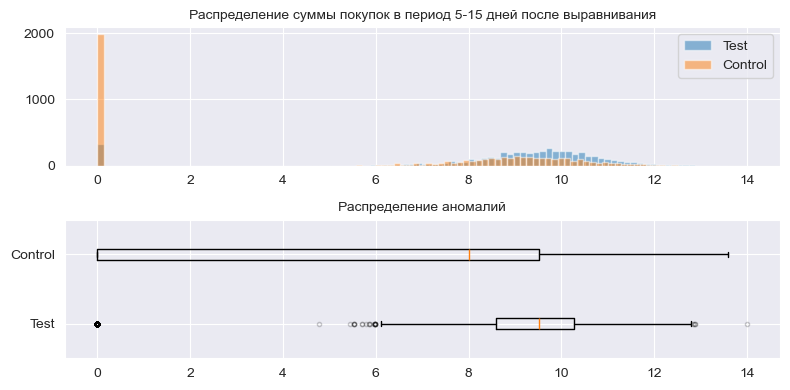

In [44]:
_, ax = plt.subplots(2, 1, figsize=(8, 4))
plt.subplots_adjust(hspace=.4)

groups = []
for gr in df_ab_5_15['is_control_group'].unique():
    ser = np.log1p(df_ab_5_15.loc[df_ab_5_15['is_control_group'] == gr, 'arpu_5_15'])
    groups += [ser]
    ax[0].hist(ser, bins=100, alpha=.5)
ax[0].legend(['Test', 'Control'])
ax[0].set_title(f'Распределение суммы покупок в период 5-15 дней после выравнивания', fontsize=10)
ax[1].boxplot(groups, tick_labels=['Test', 'Control'],  vert=False, flierprops={'marker':'.', 'alpha':0.2})
ax[1].set_title(f'Распределение аномалий', fontsize=10)
plt.tight_layout()

file_name = 'ab_5_15_log_distr.png'
full_path = os.path.join(BASE_DIR, IMAGE_FOLDER, file_name)
plt.savefig(full_path, bbox_inches='tight')

plt.show()

In [45]:
df_ab_5_15_log = df_ab_5_15.copy()
df_ab_5_15_log['arpu_5_15'] = np.log1p(df_ab_5_15_log['arpu_5_15'])


report_list = ab_ttest(df_ab_5_15_log, col='arpu_5_15', alpha=.05)
report_list[3] = round(np.expm1(report_list[2]) * 100, 1)
report_list[4] = np.nan
df_report.loc[df_report.shape[0], :] = ['arpu_5_15_log'] + report_list

Тестовая группа: 5000
Контрольная группа: 5000
На уровне значимости 5% нулевая гипотеза о равенстве выборок = True, (p-value: 1.0)
На уровне значимости 5% нулевая гипотеза о равенстве дисперсий в выборках = False (p-value: 0.0)
На уровне значимости 5% нулевая гипотеза о равенстве средних в выборках = False (p-value: 0.000)
Средние значения в выборках:
	тестовая 8.92
	контрольная 5.55
Разница Средних: 3.38
Доверительный интервал: (3.23, 3.52)


In [46]:
metric_list = ['arpu', 'arpu_log', 'arpu_5_15', 'arpu_5_15_log']
df_report[df_report['metric'].isin(metric_list)]

,metric,test,control,difference,uplift_%,ci,p_value
0,arpu,26705.9,22367.65,4338.25,19.4,"[2761.15, 5915.35]",0.0
4,arpu_log,9.19,9.26,-0.08,-7.7,NaN,0.0353
19,arpu_5_15,24832.06,13483.06,11349.0,84.2,"[9917.66, 12780.34]",0.0
20,arpu_5_15_log,8.92,5.55,3.38,2837.1,NaN,0.0


После исключения 16-го дня результат t-test резко меняется: ARPU test за период 5–15 составляет 24 832 против 13 483 в control, uplift = 84.2%, p-value < 0.001.

Log-transform на периоде 5–15 также меняет знак в пользу test. Это указывает, что отрицательный эффект log-transform на полном периоде 5–16, скорее всего, связан не с устойчиво худшим поведением test, а с аномальным 16-м днем в control.

На графике распределения за 5–15 видно, что в control сохраняется большая масса пользователей около нуля, тогда как в test больше пользователей с положительной выручкой. Поэтому результат 5–15 лучше соответствует ожидаемой логике промо: персональная скидка повышает активность и выручку test относительно control.

Таким образом, полный период 5–16 нельзя интерпретировать без оговорки: итоговый результат чувствителен к локальной аномалии control на 16-й день, причины которой установить не удалось в силу ограниченности исходной информации.

### Сегментный анализ по категориям товаров, брендам и городам

Сегментный анализ проведен на периоде 5–15, так как в полном периоде 5–16 обнаружена локальная аномалия control на 16-й день, способная искажать сетку сегментов.

Для сегментного анализа отбираются товарные/брендовые сегменты, которые формируют основную долю выручки. Базово использован порог 80% нарастающей выручки. Остальные сегменты объединены в группу 'other'.

По каждому сегменту считаются

- Продажи test/control
- кол-во покупок/товарных строк
- абсолютная разница в продажах между тестом и контролем
- относительный прирост в продажах между тестом и контролем

In [47]:
def segmentation(df, col='product_name', threshold=.8):
    mask_t = df['id'].isin(test_list)
    mask_c =  df['id'].isin(control_list)
    mask_5_15 = df['dt'].between(5, 15)

    df_segmented = (
        pd.merge(
            (
                df.loc[mask_5_15 & mask_t, [col, 'cost']]
                .groupby(col, as_index=False)
                .agg({'cost': ['count', 'sum']})
                .set_axis([col, 'quantity_t', 'amount_t'], axis=1)
            ),
            (
                df.loc[mask_5_15 & mask_c, [col, 'cost']]
                .groupby(col, as_index=False)
                .agg({'cost': ['count', 'sum']})
                .set_axis([col, 'quantity_c', 'amount_c'], axis=1)
            ),
            on=col,
            how='outer'
        )
        .fillna(0)
        .assign(total_amount=lambda x: x['amount_t'] + x['amount_c'])
        .sort_values('total_amount', ascending=False)
        .assign(cumul_amount=lambda x: x['total_amount'].cumsum() / x['total_amount'].sum() < threshold)
        .assign(category_name=lambda x: x[col].where(x['cumul_amount'] == True, 'other'))
        .drop(columns=[col, 'cumul_amount', 'total_amount'])
        .groupby('category_name', as_index=False).sum()
        .sort_values('amount_t', ascending=False)
        .assign(quantity_uplift=lambda x: x['quantity_t'] - x['quantity_c'])
        .assign(quantity_uplift_rel=lambda x: round(x['quantity_uplift'] / x['quantity_c'] * 100, 1))
        .fillna(0)
        .assign(sales_uplift=lambda x: x['amount_t'] - x['amount_c'])
        .assign(sales_uplift_rel=lambda x: round(x['sales_uplift'] / x['amount_c'] * 100, 1))
        .fillna(0)
    )
    return df_segmented

Товарные категории

In [64]:
df_segmented = segmentation(df_purchases_all, 'product_name')

In [65]:
# топ 10 категорий по абсолютному приросту выручки
df_segmented.sort_values('sales_uplift', ascending=False).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,other,8301.0,25151126.0,4355.0,13793282.0,3946.0,90.6,11357844.0,82.3
1,кроссовки,2910.0,21354760.0,1482.0,11168169.0,1428.0,96.4,10186591.0,91.2
2,велосипед,434.0,15391398.0,298.0,9956536.0,136.0,45.6,5434862.0,54.6
3,полуботинки,1009.0,6604371.0,496.0,3388814.0,513.0,103.4,3215557.0,94.9
4,куртка,814.0,6283438.0,413.0,3187398.0,401.0,97.1,3096040.0,97.1
5,брюки,1468.0,5050490.0,786.0,2575146.0,682.0,86.8,2475344.0,96.1
6,кеды,919.0,5475876.0,544.0,3303986.0,375.0,68.9,2171890.0,65.7
7,ветровка,609.0,3420981.0,303.0,1557727.0,306.0,101.0,1863254.0,119.6
8,сандалии,726.0,3036168.0,344.0,1390447.0,382.0,111.0,1645721.0,118.4
9,ботинки,325.0,3741205.0,174.0,2095506.0,151.0,86.8,1645699.0,78.5


In [66]:
# топ 10 категорий по абсолютному падению выручки
df_segmented.sort_values('sales_uplift', ascending=True).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,электровелосипед,15.0,1081493.0,11.0,786097.0,4.0,36.4,295396.0,37.6
1,сабо,156.0,713884.0,85.0,414085.0,71.0,83.5,299799.0,72.4
2,свитшот,292.0,897714.0,154.0,499479.0,138.0,89.6,398235.0,79.7
3,коньки,81.0,910019.0,45.0,445815.0,36.0,80.0,464204.0,104.1
4,слипоны,265.0,977005.0,120.0,468080.0,145.0,120.8,508925.0,108.7
5,жилет,120.0,836244.0,54.0,286916.0,66.0,122.2,549328.0,191.5
6,костюм,209.0,1472521.0,134.0,920100.0,75.0,56.0,552421.0,60.0
7,рюкзак,346.0,1438107.0,202.0,865605.0,144.0,71.3,572502.0,66.1
8,бутсы,151.0,882219.0,65.0,287345.0,86.0,132.3,594874.0,207.0
9,худи,432.0,1505088.0,219.0,749401.0,213.0,97.3,755687.0,100.8


In [50]:
# топ 10 категорий по относительному приросту выручки
df_segmented.sort_values('sales_uplift_rel', ascending=False).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,тренажер,57.0,1533625.0,10.0,385090.0,47.0,470.0,1148535.0,298.3
1,бутсы,151.0,882219.0,65.0,287345.0,86.0,132.3,594874.0,207.0
2,жилет,120.0,836244.0,54.0,286916.0,66.0,122.2,549328.0,191.5
3,дорожка,29.0,1588971.0,15.0,600585.0,14.0,93.3,988386.0,164.6
4,джемпер,409.0,1567531.0,162.0,600788.0,247.0,152.5,966743.0,160.9
5,пуховик,125.0,1771105.0,56.0,792804.0,69.0,123.2,978301.0,123.4
6,ветровка,609.0,3420981.0,303.0,1557727.0,306.0,101.0,1863254.0,119.6
7,сандалии,726.0,3036168.0,344.0,1390447.0,382.0,111.0,1645721.0,118.4
8,толстовка,395.0,1499305.0,201.0,714179.0,194.0,96.5,785126.0,109.9
9,слипоны,265.0,977005.0,120.0,468080.0,145.0,120.8,508925.0,108.7


Основной абсолютный прирост выручки пришелся на массовые товарные категории: кроссовки, велосипеды, полуботинки, куртки и брюки. Это говорит, что эффект кампании не сосредоточен в одной узкой категории, а распределен по нескольким крупным товарным направлениям.

Относительный прирост выше у некоторых менее крупных категорий, однако такие результаты нужно интерпретировать с учетом меньшей базы продаж (тренажер, бутсы, жилет, дорожка, джемпер).

Бренды

In [67]:
df_segmented = segmentation(df_purchases_all, 'product_brand')

In [52]:
# топ 10 категорий по абсолютному приросту выручки
df_segmented.sort_values('sales_uplift', ascending=False).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,other,4177.0,25133961.0,2208.0,13891578.0,1969.0,89.2,11242383.0,80.9
1,columbia,1385.0,7369255.0,679.0,3468511.0,706.0,104.0,3900744.0,112.5
2,nike,905.0,8229335.0,479.0,4706991.0,426.0,88.9,3522344.0,74.8
3,puma,1327.0,6978643.0,676.0,3480149.0,651.0,96.3,3498494.0,100.5
4,demix,3037.0,5996668.0,1545.0,3120946.0,1492.0,96.6,2875722.0,92.1
5,salomon,375.0,5243645.0,187.0,2418413.0,188.0,100.5,2825232.0,116.8
6,stern,763.0,8492323.0,430.0,5723036.0,333.0,77.4,2769287.0,48.4
7,outventure,2230.0,6302497.0,1170.0,3587575.0,1060.0,90.6,2714922.0,75.7
8,northland,1136.0,5122846.0,510.0,2524470.0,626.0,122.7,2598376.0,102.9
9,fila,1747.0,4671518.0,956.0,2547576.0,791.0,82.7,2123942.0,83.4


In [68]:
# топ 10 категорий по абсолютному падению выручки
df_segmented.sort_values('sales_uplift', ascending=True).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,e-forward,8.0,549600.0,8.0,566400.0,0.0,0.0,-16800.0,-3.0
1,noname,167.0,843439.0,82.0,777921.0,85.0,103.7,65518.0,8.4
2,champion,92.0,521478.0,61.0,384539.0,31.0,50.8,136939.0,35.6
3,protest,264.0,590781.0,171.0,377879.0,93.0,54.4,212902.0,56.3
4,reaction,123.0,600415.0,107.0,372423.0,16.0,15.0,227992.0,61.2
5,denton,101.0,1797249.0,82.0,1525518.0,19.0,23.2,271731.0,17.8
6,polygon,12.0,993988.0,9.0,716191.0,3.0,33.3,277797.0,38.8
7,joss,556.0,632989.0,268.0,317467.0,288.0,107.5,315522.0,99.4
8,ecco,94.0,1006406.0,64.0,675476.0,30.0,46.9,330930.0,49.0
9,stark,12.0,874380.0,8.0,534220.0,4.0,50.0,340160.0,63.7


In [53]:
# топ 10 категорий по относительному приросту выручки
df_segmented.sort_values('sales_uplift_rel', ascending=False).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,kettler,151.0,1933959.0,66.0,512534.0,85.0,128.8,1421425.0,277.3
1,new balance,103.0,1686897.0,39.0,607161.0,64.0,164.1,1079736.0,177.8
2,icepeak,166.0,861614.0,71.0,319169.0,95.0,133.8,542445.0,170.0
3,jack,16.0,1125064.0,10.0,427240.0,6.0,60.0,697824.0,163.3
4,merrell,225.0,1240705.0,86.0,484084.0,139.0,161.6,756621.0,156.3
5,nordictrack,5.0,671995.0,3.0,272997.0,2.0,66.7,398998.0,146.2
6,torneo,274.0,2188882.0,145.0,946835.0,129.0,89.0,1242047.0,131.2
7,skechers,615.0,2414940.0,272.0,1051258.0,343.0,126.1,1363682.0,129.7
8,salomon,375.0,5243645.0,187.0,2418413.0,188.0,100.5,2825232.0,116.8
9,columbia,1385.0,7369255.0,679.0,3468511.0,706.0,104.0,3900744.0,112.5


По брендам прирост распределен между несколькими крупными брендами, а не сосредоточен в одном. Это поддерживает вывод о достаточно широком эффекте кампании.

По относительному приросту сильные значения у kettler, geox, li-ning, new balance, но здесь нужно держать в уме и абсолютную выручку вкупе с количеством покупок

Города

In [61]:
df_segmented = segmentation(df_purchases, 'city')

In [62]:
# топ 10 городов по абсолютному приросту выручки
df_segmented.sort_values('sales_uplift', ascending=False).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,other,5009.0,26492285.0,2317.0,12002420.0,2692.0,116.2,14489865.0,120.7
1,1134,5586.0,30931299.0,3027.0,17381902.0,2559.0,84.5,13549397.0,78.0
2,1188,2404.0,12578297.0,1295.0,7404624.0,1109.0,85.6,5173673.0,69.9
3,1157,800.0,4397902.0,395.0,1744022.0,405.0,102.5,2653880.0,152.2
4,1178,854.0,4559251.0,336.0,1921733.0,518.0,154.2,2637518.0,137.2
5,1187,600.0,3556188.0,231.0,977416.0,369.0,159.7,2578772.0,263.8
6,1167,802.0,4107482.0,390.0,1668903.0,412.0,105.6,2438579.0,146.1
7,1150,333.0,2029632.0,62.0,227139.0,271.0,437.1,1802493.0,793.6
8,1159,220.0,2099335.0,165.0,740246.0,55.0,33.3,1359089.0,183.6
9,1177,642.0,3016912.0,339.0,1717151.0,303.0,89.4,1299761.0,75.7


In [63]:
# топ 10 городов по абсолютному падению выручки
df_segmented.sort_values('sales_uplift', ascending=True).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,1165,198.0,853947.0,124.0,1198082.0,74.0,59.7,-344135.0,-28.7
1,1203,208.0,964409.0,205.0,1255577.0,3.0,1.5,-291168.0,-23.2
2,1201,452.0,2066571.0,349.0,2325886.0,103.0,29.5,-259315.0,-11.1
3,1170,93.0,633775.0,88.0,802259.0,5.0,5.7,-168484.0,-21.0
4,1168,362.0,1919585.0,283.0,1996131.0,79.0,27.9,-76546.0,-3.8
5,1202,203.0,1308838.0,215.0,1057201.0,-12.0,-5.6,251637.0,23.8
6,1145,175.0,877513.0,97.0,596219.0,78.0,80.4,281294.0,47.2
7,1183,462.0,1778194.0,288.0,1466880.0,174.0,60.4,311314.0,21.2
8,1185,265.0,1598247.0,211.0,1239026.0,54.0,25.6,359221.0,29.0
9,1156,301.0,1288449.0,155.0,910398.0,146.0,94.2,378051.0,41.5


In [56]:
# топ 10 городов по относительному приросту выручки
df_segmented.sort_values('sales_uplift_rel', ascending=False).head(10).reset_index(drop=True)

,category_name,quantity_t,amount_t,quantity_c,amount_c,quantity_uplift,quantity_uplift_rel,sales_uplift,sales_uplift_rel
0,1150,333.0,2029632.0,62.0,227139.0,271.0,437.1,1802493.0,793.6
1,1141,251.0,1229123.0,82.0,329258.0,169.0,206.1,899865.0,273.3
2,1187,600.0,3556188.0,231.0,977416.0,369.0,159.7,2578772.0,263.8
3,1198,306.0,1448376.0,87.0,479183.0,219.0,251.7,969193.0,202.3
4,1159,220.0,2099335.0,165.0,740246.0,55.0,33.3,1359089.0,183.6
5,1157,800.0,4397902.0,395.0,1744022.0,405.0,102.5,2653880.0,152.2
6,1167,802.0,4107482.0,390.0,1668903.0,412.0,105.6,2438579.0,146.1
7,1190,328.0,1429649.0,113.0,587450.0,215.0,190.3,842199.0,143.4
8,1171,174.0,1054250.0,73.0,434628.0,101.0,138.4,619622.0,142.6
9,1178,854.0,4559251.0,336.0,1921733.0,518.0,154.2,2637518.0,137.2


На уровне городов крупнейший абсолютный прирост показал город 1134. Также сильные города: 1188, 1157, 1178, 1187, 1167.

Среди клиентов особенным успехом пользовалось промо в городе 1150 - он показал огромный относительный прирост. Это отличный локальный сигнал, но основной абсолютный прирост кампании формируется в других, более крупных городах.

На уровне городов есть несколько локальных просадок: 1165, 1203, 1201, 1170 и 1168. Самое сильное абсолютное падение наблюдается в городе 1165: -344 тыс. руб., или -28.7% к control. Эти просадки локальны и заметно меньше положительного прироста в городах-драйверах, поэтому они не меняют общий вывод об эффективности кампании, но их стоит отметить как зоны риска для последующей проверки.

# Итоговый вывод и бизнес-рекомендация

Кампания показала статистически значимый рост ARPU на полном периоде 5-16: uplift составил 19.4%. Bootstrap подтвердил устойчивость эффекта, а winsorization и анализ клиентов, формирующих верхние 20% выручки, показали, что результат не держится только на крупнейших покупателях.

При этом в control обнаружена локальная аномалия на 16-й день: в этот день активными стали все пользователи контрольной группы, что привело к резкому скачку выручки. Источник аномалии не удалось восстановить по доступным данным: она не выглядит вызванной top-1% клиентов, отдельным товарным, брендовым или географическим сегментом.

После исключения 16-го дня эффект кампании становится еще сильнее: ARPU test за период 5-15 значительно выше control, uplift составляет 84.2%. Это говорит, что аномалия control скорее занижала видимый эффект кампании на полном периоде, а не создавала его искусственно.

Guardrail-метрики в постпериодах статистически значимо не ухудшились, поэтому явных признаков смещения будущего спроса не обнаружено.

Рекомендация: кампанию можно считать эффективной по выручке и рассматривать к масштабированию, но перед повторным запуском стоит проверить причину аномальной активности control на 16-й день, дополнительно контролировать дневную динамику выручки, CR и вклад крупнейших покупателей. Также города с отрицательным эффектом стоит проверить отдельно: возможно, в них промо хуже попало в спрос, ассортимент или местную аудиторию.